In [1]:
import sys
print("Python:", sys.executable)

import boto3
print("boto3:", boto3.__version__)

import pyathena
print("pyathena:", pyathena.__version__)

import pandas as pd
print("pandas:", pd.__version__)

Python: /Users/atharva/aws-mlops-fraud-detection/.venv/bin/python
boto3: 1.34.0
pyathena: 3.0.10
pandas: 2.1.4


In [4]:
# Cell 1 — Setup
import os
import warnings
from pathlib import Path

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyathena import connect

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

# Load environment variables from .env (the file you created in Phase 1)
from dotenv import load_dotenv
load_dotenv(Path("..") / ".env")  # notebook is in notebooks/, .env is one level up

PROJECT_BUCKET = os.environ["PROJECT_BUCKET"]
AWS_REGION = os.environ.get("AWS_REGION", "ap-south-1")
ATHENA_DB = "mlops_fraud_detection"
ATHENA_TABLE = "raw_creditcard"
ATHENA_RESULTS = f"s3://{PROJECT_BUCKET}/athena-results/"

print(f"Bucket:  {PROJECT_BUCKET}")
print(f"Region:  {AWS_REGION}")
print(f"Athena:  {ATHENA_DB}.{ATHENA_TABLE}")

# Sanity check: AWS credentials are loaded
sts = boto3.client("sts")
print(f"AWS account: {sts.get_caller_identity()['Account']}")

Bucket:  mlops-fraud-detection-atharva-1777831686
Region:  ap-south-1
Athena:  mlops_fraud_detection.raw_creditcard
AWS account: 376142073754


In [6]:
# Cell 2 — Connect to Athena and load the dataset

conn = connect(
    s3_staging_dir=ATHENA_RESULTS,
    region_name=AWS_REGION,
)

# Build a query that CASTs every string column to its proper numeric type.
# This is ugly but it's what we have to do until Phase 2B converts to Parquet.
v_columns = [f"CAST(v{i} AS DOUBLE) AS v{i}" for i in range(1, 29)]
query = f"""
SELECT
    CAST(time AS DOUBLE) AS time,
    {', '.join(v_columns)},
    CAST(amount AS DOUBLE) AS amount,
    CAST(class AS INTEGER) AS class
FROM {ATHENA_DB}.{ATHENA_TABLE}
"""

print("Running Athena query (this scans ~144 MB, takes ~5-10 seconds)...")
df = pd.read_sql(query, conn)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df.head()

Running Athena query (this scans ~144 MB, takes ~5-10 seconds)...
Loaded 284,807 rows × 31 columns


,time,v1,v2,v3,v4,v5,v6,v7,v8,v9,v10,v11,v12,v13,v14,v15,v16,v17,v18,v19,v20,v21,v22,v23,v24,v25,v26,v27,v28,amount,class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
# Cell 3 — Quick orientation
print(f"Shape:        {df.shape}")
print(f"Columns:      {list(df.columns)}")
print(f"Memory usage: {df.memory_usage().sum() / 1024 / 1024:.1f} MB")
print()
print("Class distribution:")
print(df["class"].value_counts())
print(f"\nFraud rate: {df['class'].mean() * 100:.4f}%")
print(f"\nMissing values: {df.isnull().sum().sum()}")

Shape:        (284807, 31)
Columns:      ['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class']
Memory usage: 67.4 MB

Class distribution:
class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%

Missing values: 0


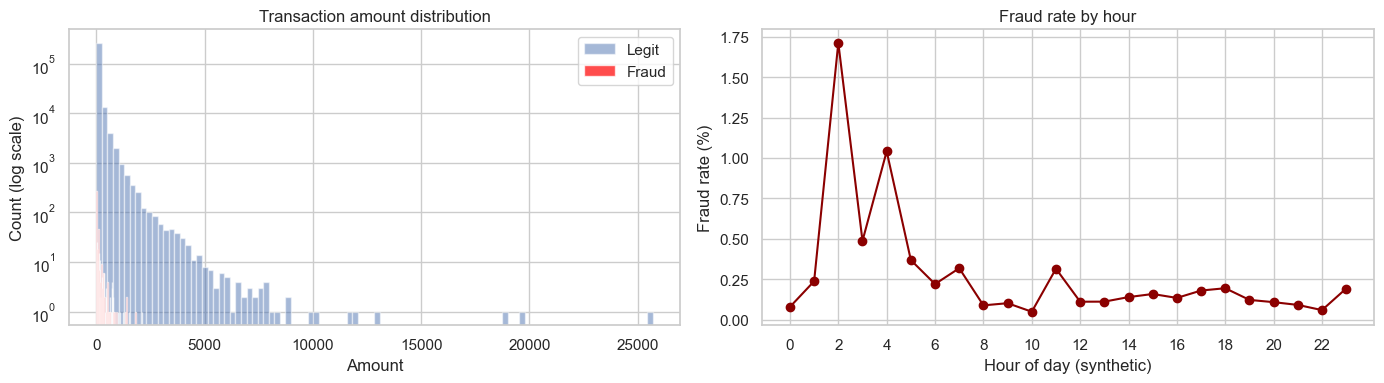

In [8]:
# Cell 4 — Visualize the obvious stuff first
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount distribution (log scale because it's heavy-tailed)
axes[0].hist(df[df["class"] == 0]["amount"], bins=100, alpha=0.5, label="Legit", log=True)
axes[0].hist(df[df["class"] == 1]["amount"], bins=100, alpha=0.7, label="Fraud", log=True, color="red")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Transaction amount distribution")
axes[0].legend()

# Time distribution: convert seconds to hour-of-day
df["hour"] = (df["time"] // 3600) % 24
fraud_by_hour = df[df["class"] == 1].groupby("hour").size() / df.groupby("hour").size()
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values * 100, marker="o", color="darkred")
axes[1].set_xlabel("Hour of day (synthetic)")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_title("Fraud rate by hour")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

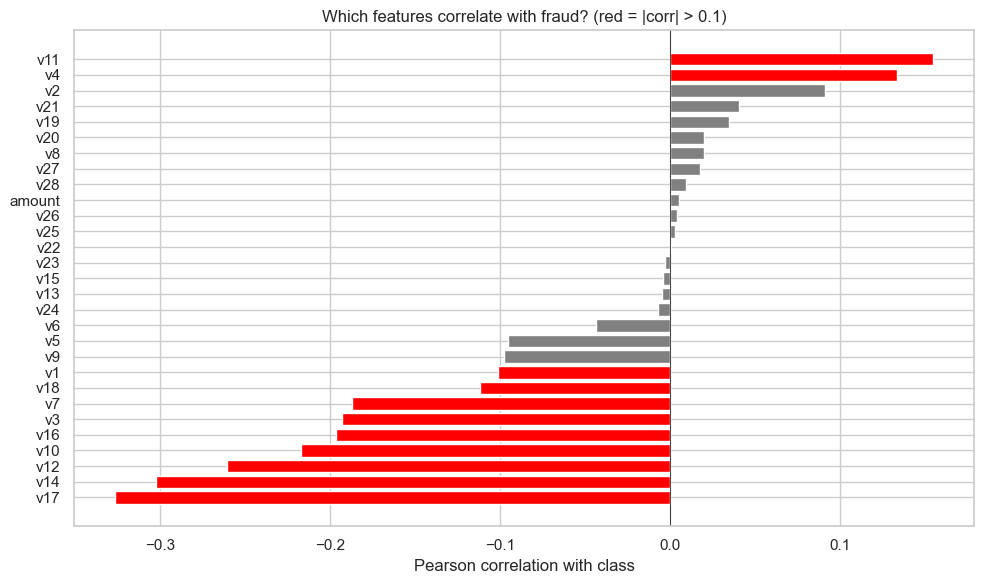

Top 5 most predictive features (absolute correlation):
v17    0.326481
v14    0.302544
v12    0.260593
v10    0.216883
v16    0.196539
Name: class, dtype: float64


In [9]:
# Cell 5 — Correlation of each V feature with the class label
v_cols = [f"v{i}" for i in range(1, 29)]
correlations = df[v_cols + ["amount", "class"]].corr()["class"].drop("class").sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["red" if abs(c) > 0.1 else "gray" for c in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Pearson correlation with class")
ax.set_title("Which features correlate with fraud? (red = |corr| > 0.1)")
plt.tight_layout()
plt.show()

print("Top 5 most predictive features (absolute correlation):")
print(correlations.abs().sort_values(ascending=False).head())

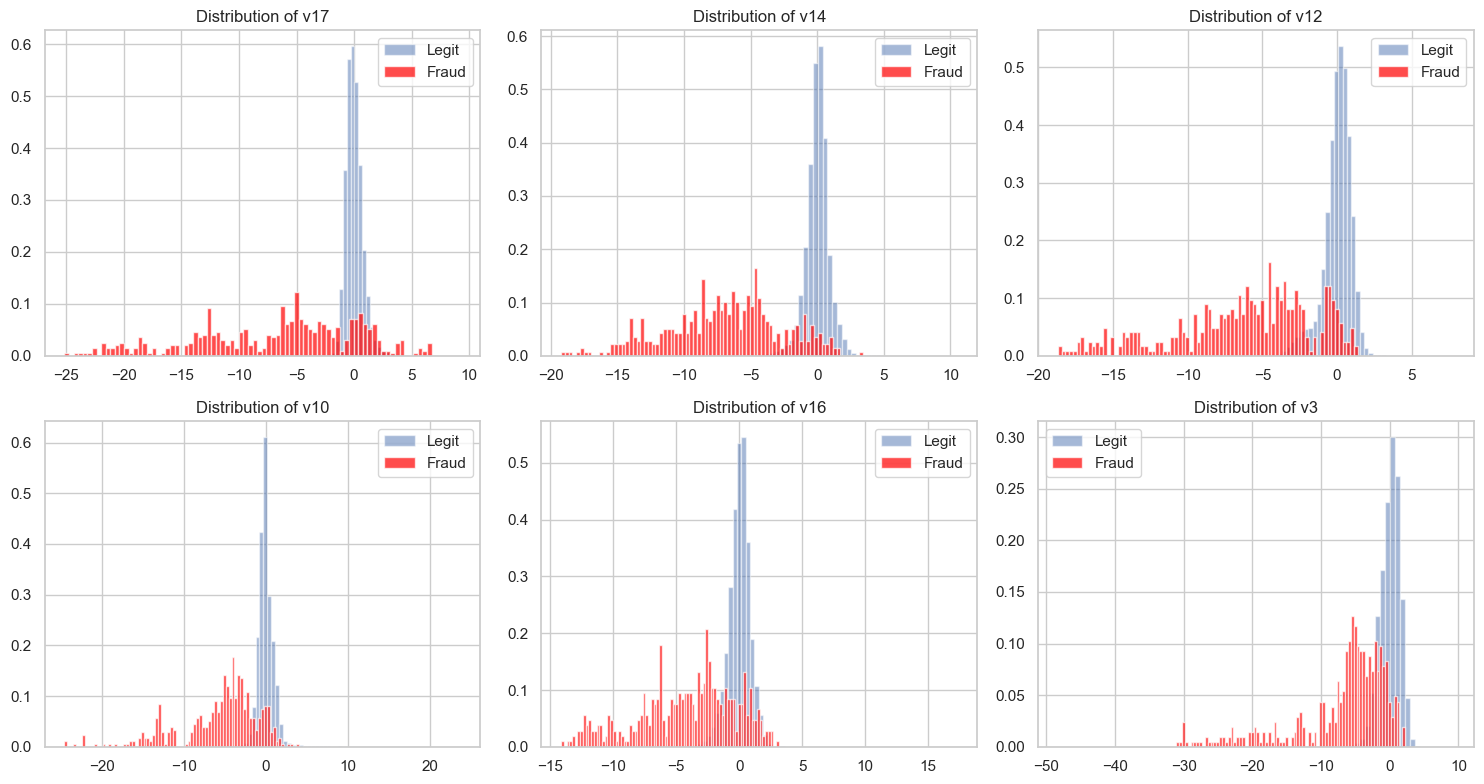

In [10]:
# Cell 6 — Distribution of top features split by class
top_features = correlations.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(top_features):
    ax = axes[i // 3, i % 3]
    ax.hist(df[df["class"] == 0][feat], bins=80, alpha=0.5, label="Legit", density=True)
    ax.hist(df[df["class"] == 1][feat], bins=80, alpha=0.7, label="Fraud", density=True, color="red")
    ax.set_title(f"Distribution of {feat}")
    ax.legend()
plt.tight_layout()
plt.show()